In [1]:
from sim import run_sim
from utils import render_grid_frame_arena, make_two_rooms_with_corridor, grid
import numpy as np
import pandas as pd
import tqdm
import itertools
import os

In [2]:
# Init
output_folder = 'runs'
history_folder = 'pkls'
os.makedirs(output_folder, exist_ok=True)
os.makedirs(os.path.join(output_folder, history_folder), exist_ok=True)

# history = {'init': {'forgetting_rates': {'M_fr' : M_forgetting_rate, 'T_fr': T_forgetting_rate, 'D_fr': D_forgetting_rate}, 
#                 'ticks': {'T_ticks': T_ticks, 'D_ticks': D_ticks},
#                 'base_scale': base_scale,
#                 'T_act_1': T_control_scales[1],
#                 'D_act_1': D_control_scales[1],
#                 'detection_threshold': danger_detection_threshold,
#                 'utils': {'M': {'agent': U_agent_base, 'shelter': U_shelter_base, 'threat': U_threat_base},
#                           'T': U_T,
#                           'D': U_D},
#                 'M_act_habits_single': E_single,
#                 'threat_loc': rightcol_states[0],
#                 'shelter_loc': np.array(leftcol_states),
#                 }, 
#        'agent_loc': [], 
#                         'M_beliefs': [], 'M_util': [],  'M_info_gain': [], 'M_q_pi': [], 'M_neg_efe': [], 'M_action': [], 
#                         'T_beliefs': [], 'T_util': [], 'T_info_gain': [], 'T_q_pi': [], 'T_neg_efe': [], 'T_act_t': [], 'T_action': [],
#                         'D_beliefs': [], 'D_util': [], 'D_info_gain': [], 'D_q_pi': [], 'D_neg_efe': [], 'D_act_t': [], 'D_action': [],}

mask, regions = make_two_rooms_with_corridor(4, 0, 3, 2, (1,2), prefer_total_cols=None)

map = grid(mask=mask)

In [3]:
# Defining metrics
def t_social_investigation(history, arena, parts=1, d_threshold=1):
    agent_locs = history['agent_loc']
    total_t = len(agent_locs)
    threat_state = int(history['init']['threat_loc']) 
    chunk_size = total_t // parts
    
    results = []

    for i in range(parts):
        start_idx = i * chunk_size
        if i == parts - 1:
            end_idx = total_t
        else:
            end_idx = (i + 1) * chunk_size
        segment = agent_locs[start_idx:end_idx]
        investigating_t = 0
        for agent_state in segment:
            if arena.manhattan_states(agent_state, threat_state) <= d_threshold:
                investigating_t += 1
        results.append(investigating_t / len(segment))

    return results

def t_shelter(history, parts=1):
    agent_locs = history['agent_loc']
    total_t = len(agent_locs)

    shelter_states = history['init']['shelter_loc']
    
    chunk_size = total_t // parts
    results = []

    for i in range(parts):
        start_idx = i * chunk_size
        if i == parts - 1:
            end_idx = total_t
        else:
            end_idx = (i + 1) * chunk_size
        
        segment = agent_locs[start_idx:end_idx]
        shelter_t = 0

        for agent_state in segment:
            if agent_state in shelter_states:
                shelter_t += 1
        results.append(shelter_t / len(segment))
    return results

# def t_retreat():
#     return

In [4]:
default_params = {
    'gif_path': None,
    'pkl_path': None,
    'M_fr': 0.1, 
    'D_fr': 0.1, 
    'T_fr': 0.2, 
    'max_steps': 1000, 
    'id_threshold': 0.8,
    'T_ticks': 4, 
    'D_ticks': 16, 
    'k_shelter': 0.6, 
    'k_threat': 0.8, 
    'threat_grad': [-0.1, -0.1, -0.2, -0.25], 
    'shelter_grad': [-0.1, 0.1, 0.15, 0.2, 0.3],
    'delta_stay': 0.15, 
    'epistemic_drive': 1.0, 
    'T_scale': (-0.3, -0.3), 
    'D_scale': (0.5, 0.7)
}

param_grid = {
    'M_fr': [0.1, 0.2, 0.3],
    'T_scale': [
        (-0.3, -0.3),
        (-0.5, -0.5),
        (-0.1, -0.1)
    ],
    # 'threat_grad': [
    #     [-0.1, -0.1, -0.2, -0.25],
    #     [-0.5, -0.5, -0.8, -1.0],
    #     [0.0, 0.0, 0.0, 0.0]
    # ]
}

# run_history = run_sim(gif_path=None, pkl_path=None, M_fr=0.1, D_fr=0.1, T_fr=0.2, max_steps=1000, id_threshold=0.8, \
#             T_ticks=4, D_ticks=16, k_shelter=0.6, k_threat=0.8, threat_grad=[-0.1, -0.1, -0.2, -0.25], shelter_grad=[-0.1, 0.1, 0.15, 0.2, 0.3], \
#             delta_stay=0.15, epistemic_drive=1.0, T_scale=(-0.3, -0.3), D_scale=(0.5, 0.7))

# generate all combinations from the grid
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total simulations to run: {len(combinations)}")


Total simulations to run: 9


In [5]:
run_name = 'saturation_test'
results = []

# Iterate through combinations
for i, varying_params in tqdm.tqdm(enumerate(combinations)):
    current_run_config = default_params.copy()
    current_run_config.update(varying_params)

    current_run_config['pkl_path'] = f'runs/pkls/{run_name}_{i}.pkl'

    run_history = run_sim(**current_run_config)
    
    log_entry = varying_params.copy()

    segments = 5
    t_si = t_social_investigation(run_history, map, segments)
    t_sh = t_shelter(run_history, segments)

    for j in range(segments):
        log_entry[f'SocialInvestigation_{j}'] = t_si[j]
        log_entry[f'Shelter_{j}'] = t_sh[j]

    results.append(log_entry)

print('Simulations complete')

0it [00:00, ?it/s]

Arena mask shape: (4, 5)
Passable cells count: 14
Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14
Built A with shapes: [(4, 14, 14, 14), (5, 14, 14, 14), (14, 14, 14, 14)]
Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 Threat prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0
C (log pref): [array([[-1.33763884, -1.33763884],
       [-1.33763884, -1.33763884],
       [-1.41763884, -1.41763884],
       [-1.45763884, -1.45763884]]), array([[-1.75055504, -1.75055504],
       [-1.63055504, -1.63055504],
       [-1.60055504, -1.60055504],
       [-1.57055504, -1.57055504],
       [-1.51055504, -1.51055504]]), array([[-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905

1it [03:36, 216.41s/it]

Simulation finished
Arena mask shape: (4, 5)
Passable cells count: 14
Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14
Built A with shapes: [(4, 14, 14, 14), (5, 14, 14, 14), (14, 14, 14, 14)]
Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 Threat prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0
C (log pref): [array([[-1.33763884, -1.33763884],
       [-1.33763884, -1.33763884],
       [-1.41763884, -1.41763884],
       [-1.45763884, -1.45763884]]), array([[-1.75055504, -1.75055504],
       [-1.63055504, -1.63055504],
       [-1.60055504, -1.60055504],
       [-1.57055504, -1.57055504],
       [-1.51055504, -1.51055504]]), array([[-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.6390573

2it [07:15, 217.91s/it]

...

Simulation finished
Arena mask shape: (4, 5)
Passable cells count: 14
Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14
Built A with shapes: [(4, 14, 14, 14), (5, 14, 14, 14), (14, 14, 14, 14)]
Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 Threat prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0
C (log pref): [array([[-1.33763884, -1.33763884],
       [-1.33763884, -1.33763884],
       [-1.41763884, -1.41763884],
       [-1.45763884, -1.45763884]]), array([[-1.75055504, -1.75055504],
       [-1.63055504, -1.63055504],
       [-1.60055504, -1.60055504],
       [-1.57055504, -1.57055504],
       [-1.51055504, -1.51055504]]), array([[-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.6390573

8it [27:51, 201.69s/it]

t = 997 | D set context to SAFE
Simulation finished
Arena mask shape: (4, 5)
Passable cells count: 14
Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14
Built A with shapes: [(4, 14, 14, 14), (5, 14, 14, 14), (14, 14, 14, 14)]
Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 Threat prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0
C (log pref): [array([[-1.33763884, -1.33763884],
       [-1.33763884, -1.33763884],
       [-1.41763884, -1.41763884],
       [-1.45763884, -1.45763884]]), array([[-1.75055504, -1.75055504],
       [-1.63055504, -1.63055504],
       [-1.60055504, -1.60055504],
       [-1.57055504, -1.57055504],
       [-1.51055504, -1.51055504]]), array([[-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],
       [-2.63905733, -2.63905733],

9it [31:34, 210.55s/it]

Simulation finished
Simulations complete


In [6]:
df = pd.DataFrame(results)
print(df)

   M_fr       T_scale  SocialInvestigation_0  Shelter_0  \
0   0.1  (-0.3, -0.3)                  0.345      0.005   
1   0.1  (-0.5, -0.5)                  0.345      0.030   
2   0.1  (-0.1, -0.1)                  0.530      0.005   
3   0.2  (-0.3, -0.3)                  0.500      0.005   
4   0.2  (-0.5, -0.5)                  0.550      0.005   
5   0.2  (-0.1, -0.1)                  0.340      0.005   
6   0.3  (-0.3, -0.3)                  0.450      0.005   
7   0.3  (-0.5, -0.5)                  0.500      0.005   
8   0.3  (-0.1, -0.1)                  0.385      0.005   

   SocialInvestigation_1  Shelter_1  SocialInvestigation_2  Shelter_2  \
0                  0.535       0.01                  0.220      0.000   
1                  0.495       0.00                  0.460      0.030   
2                  0.530       0.04                  0.150      0.010   
3                  0.350       0.00                  0.320      0.025   
4                  0.575       0.00         

In [7]:
# 1. Identify which columns are your Parameters (the things that don't change over time)
# Get all columns that do NOT start with 'Social_' or 'Shelter_'
param_cols = [c for c in df.columns if not (c.startswith('Social_') or c.startswith('Shelter_'))]

# 2. Melt Social Data
df_social = df.melt(
    id_vars=param_cols, 
    value_vars=[c for c in df.columns if c.startswith('Social_')],
    var_name='Time_Segment', 
    value_name='Proportion_Time'
)
# Clean up the 'Time_Segment' column (convert "Social_0" -> 0)
df_social['Time_Segment'] = df_social['Time_Segment'].str.extract('(\d+)').astype(int)
df_social['Metric_Type'] = 'Social Investigation'

# 3. Melt Shelter Data
df_shelter = df.melt(
    id_vars=param_cols, 
    value_vars=[c for c in df.columns if c.startswith('Shelter_')],
    var_name='Time_Segment', 
    value_name='Proportion_Time'
)
df_shelter['Time_Segment'] = df_shelter['Time_Segment'].str.extract('(\d+)').astype(int)
df_shelter['Metric_Type'] = 'Shelter Usage'

# 4. Combine them (Optional, if you want them on one big plot)
df_long = pd.concat([df_social, df_shelter], ignore_index=True)

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_69113/3955127315.py:13: SyntaxWarning: invalid escape sequence '\d'
  df_social['Time_Segment'] = df_social['Time_Segment'].str.extract('(\d+)').astype(int)
/tmp/ipykernel_69113/3955127315.py:23: SyntaxWarning: invalid escape sequence '\d'
  df_shelter['Time_Segment'] = df_shelter['Time_Segment'].str.extract('(\d+)').astype(int)


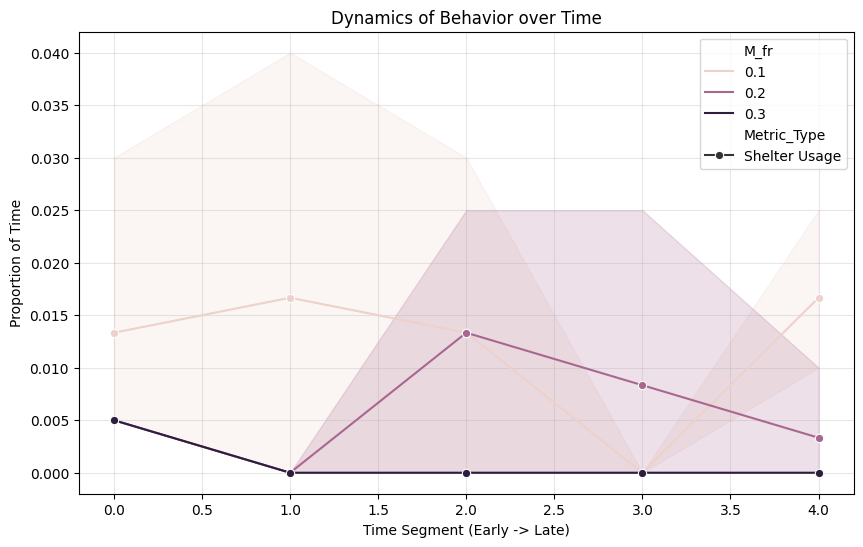

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Hue = The parameter you changed
# Style = The metric type (Social vs Shelter)
sns.lineplot(
    data=df_long, 
    x='Time_Segment', 
    y='Proportion_Time', 
    hue='M_fr', 
    style='Metric_Type',
    markers=True, 
    dashes=False
)

plt.title("Dynamics of Behavior over Time")
plt.xlabel("Time Segment (Early -> Late)")
plt.ylabel("Proportion of Time")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
df.to_csv(f"runs/{run_name}.csv", index=False)